# Image segmentation

Extend your ResNet18 implementation to include a segmentation capabilities. The simplest extension of a backbone network is to simply generate the predictions at the last convolutional feature layer and then upsample them to fit the input image dimensions as described in https://arxiv.org/pdf/1411.4038.pdf (FCN-32s).

For this exercise you will be using the following dataset: https://www.kaggle.com/kumaresanmanickavelu/lyft-udacity-challenge - You don't have to download it from kaggle as it is already hosted on drive (the script to download it is a few cells down).

For this task, implement the FCN-32s (https://arxiv.org/pdf/1411.4038.pdf), however this is one of the first and simplest fully convolutional segmentation networks and the results will be coarse. You can optionally extend your network with more complex segmentation heads.

A few network architecture that you can optionally implement to improve the results:
- the full FCN network described in https://arxiv.org/pdf/1411.4038.pdf
- PSP-Net https://arxiv.org/pdf/1612.01105.pdf
- DeeplabV3 https://arxiv.org/pdf/1706.05587.pdf


Additionally, implement the U-Net architecture https://arxiv.org/pdf/1505.04597.pdf and use it as a segmentation network. Compare it to your FCN-32s implementation.



## Network implementation

In [1]:
import torchvision
import torch
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset
import glob
import cv2
import numpy as np

import torch
from tqdm.notebook import tqdm

import matplotlib.pyplot as plt
import numpy as np


In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ResBlock(nn.Module):
    def __init__(self, in_channels, out_channels=None):
        super().__init__()
        if out_channels is not None:
            self.block = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=2, padding=1, bias=False),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False),
                nn.BatchNorm2d(out_channels),
            )
            self.skip = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=2, bias=False),
                nn.BatchNorm2d(out_channels),
            )
        else:
            self.block = nn.Sequential(
                nn.Conv2d(in_channels, in_channels, kernel_size=3, stride=1, padding=1, bias=False),
                nn.BatchNorm2d(in_channels),
                nn.ReLU(inplace=True),
                nn.Conv2d(in_channels, in_channels, kernel_size=3, stride=1, padding=1, bias=False),
                nn.BatchNorm2d(in_channels),
            )
            self.skip = None

    def forward(self, x):
        identity = x if self.skip is None else self.skip(x)
        out = self.block(x)
        return F.relu(out + identity)


class ResNet18FCN(nn.Module):
    def __init__(self, num_classes=13):
        super().__init__()

        # Initial convolutional layer
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
        )

        self.max_pool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # Residual layers
        self.conv2 = nn.Sequential(
            ResBlock(64),
            ResBlock(64),
        )
        self.conv3 = nn.Sequential(
            ResBlock(64, 128),
            ResBlock(128),
        )
        self.conv4 = nn.Sequential(
            ResBlock(128, 256),
            ResBlock(256),
        )

        # Optional deepen layer to match skip shape
        self.deepen = nn.Conv2d(256, 512, kernel_size=1)

        self.conv5 = nn.Sequential(
            ResBlock(256, 512),
            ResBlock(512),
        )

        # Upsample to match resolution before seg head
        self.lower_upsample = nn.ConvTranspose2d(
            512, 512, kernel_size=3, stride=2, padding=1, output_padding=1
        )

        # Final segmentation head
        self.segmentation_head = nn.Conv2d(512, num_classes, kernel_size=1)

        # Final upsampling to restore original image size (x16 upsampling)
        self.upsample = nn.Upsample(scale_factor=16, mode='bilinear', align_corners=True)

    def forward(self, x):
        x = self.conv1(x)
        x = self.max_pool(x)

        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)

        skip_connection = self.deepen(x)
        x = self.conv5(x)
        x = self.lower_upsample(x) + skip_connection

        x = self.segmentation_head(x)
        return self.upsample(x)


In [3]:
class UnetBlock(nn.Module):
    """Basic UNet block consisting of two convolutional layers with batch norm and ReLU."""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
            
    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    """UNet architecture for semantic segmentation.
    Based on the paper: https://arxiv.org/pdf/1505.04597.pdf
    """
    def __init__(self, num_classes=13):
        super().__init__()
        
        # Encoder (downsampling path)
        self.encoder1 = UnetBlock(3, 64)
        self.encoder2 = UnetBlock(64, 128)
        self.encoder3 = UnetBlock(128, 256)
        self.encoder4 = UnetBlock(256, 512)
        self.encoder5 = UnetBlock(512, 1024)
        
        self.pool = nn.MaxPool2d(2, 2)
        
        # Decoder (upsampling path)
        self.upconv1 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.decoder1 = UnetBlock(1024, 512)
        
        self.upconv2 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.decoder2 = UnetBlock(512, 256)
        
        self.upconv3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.decoder3 = UnetBlock(256, 128)
        
        self.upconv4 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.decoder4 = UnetBlock(128, 64)
        
        # Final output layer
        self.final_conv = nn.Conv2d(64, num_classes, kernel_size=1)
    
    def forward(self, x):
        # Encoder path
        e1 = self.encoder1(x)
        e2 = self.encoder2(self.pool(e1))
        e3 = self.encoder3(self.pool(e2))
        e4 = self.encoder4(self.pool(e3))
        
        # Bridge
        bridge = self.encoder5(self.pool(e4))
        
        # Decoder path with skip connections
        d1 = self.upconv1(bridge)
        d1 = torch.cat([e4, d1], dim=1)
        d1 = self.decoder1(d1)
        
        d2 = self.upconv2(d1)
        d2 = torch.cat([e3, d2], dim=1)
        d2 = self.decoder2(d2)
        
        d3 = self.upconv3(d2)
        d3 = torch.cat([e2, d3], dim=1)
        d3 = self.decoder3(d3)
        
        d4 = self.upconv4(d3)
        d4 = torch.cat([e1, d4], dim=1)
        d4 = self.decoder4(d4)
        
        # Final output
        out = self.final_conv(d4)
        return out

##Download the dataset
Download a part of the Lyft self driving dataset split into training and validation sets - https://www.kaggle.com/kumaresanmanickavelu/lyft-udacity-challenge


The dataset contains 13 classes:
0 - unlabeled,
1 - building,
2 - fence,
3 - other
4 - pedestrian,
5 - pole
6 - road line
7 - road
8 - sidewalk
9 - vegetation
10 - car
11 - wall
12 - traffic sign






In [4]:
#!pip install --upgrade --no-cache-dir gdown
#!gdown --id 1Mgxe0Nl19hxMhQqVvEpaRDNd_L_RaLNM
# if this link does not work try the other link
#!gdown --id 1wUFws0e5ArlYUg7NZiAjjrYOmTGCX_Fv


## Data loader

In [5]:
class SegmentationDataset(Dataset):

    def __init__(self, train=True):
        dataset_path = "./dl/data/seg_data/" + ("train" if train else "test")
        self.images = sorted(glob.glob(dataset_path+"/*/*/CameraRGB/*.png"))
        self.masks = sorted(glob.glob(dataset_path+"/*/*/CameraSeg/*.png"))
        self.resize_shape = (320, 416)

    def __len__(self):
        return len(self.images)

    def transform_image(self, image_path, mask_path):
        image = cv2.imread(image_path, cv2.IMREAD_COLOR)
        mask = cv2.imread(mask_path, cv2.IMREAD_COLOR)[:,:,2]

        channels=3
        image = cv2.resize(image, dsize=(self.resize_shape[1], self.resize_shape[0]))
        mask = cv2.resize(mask, dsize=(self.resize_shape[1], self.resize_shape[0]))
        image = np.array(image).reshape((image.shape[0], image.shape[1], channels)).astype(np.float32) / 255.0
        mask = np.array(mask).reshape((image.shape[0], image.shape[1], 1))

        image = np.transpose(image, (2, 0, 1))
        mask = np.transpose(mask, (2, 0, 1))
        return image, mask

    def __getitem__(self, idx):
        image, mask = self.transform_image(self.images[idx], self.masks[idx])
        sample = {'image': image, "mask": mask, 'idx': idx}

        return sample

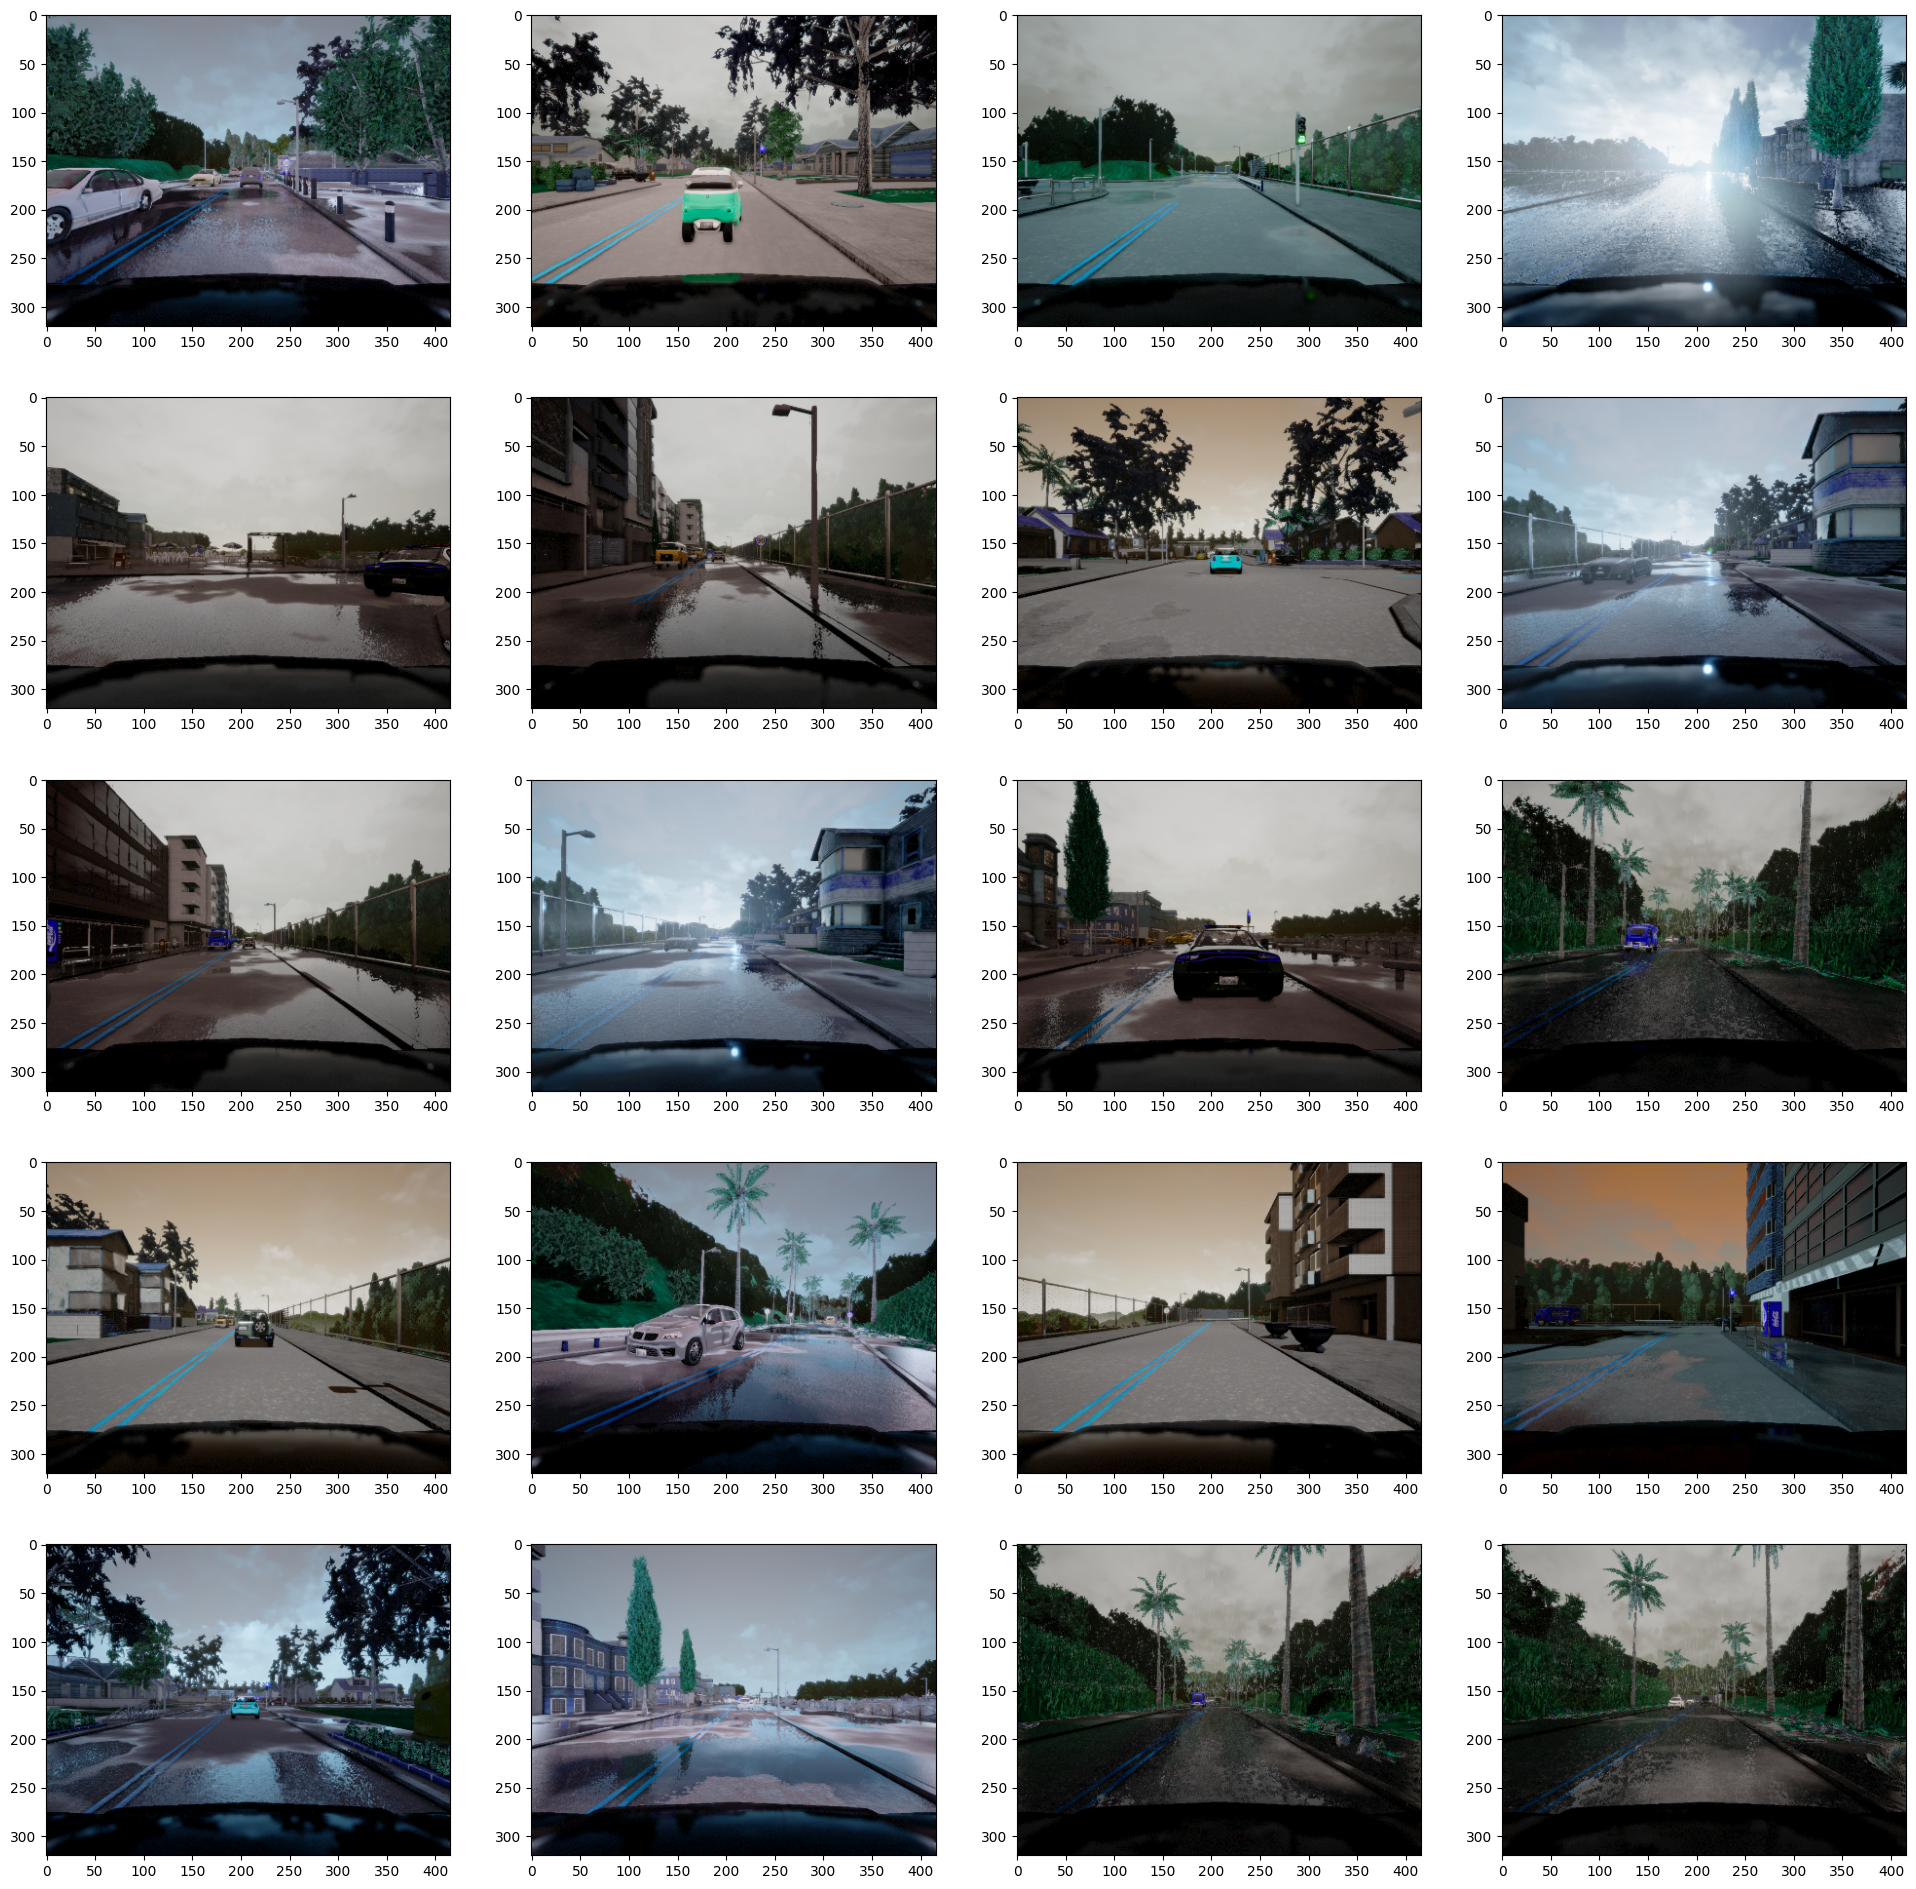

In [6]:

trainset = SegmentationDataset(train=True)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=4,
                                          shuffle=True, num_workers=2)

testset = SegmentationDataset(train=False)
testloader = torch.utils.data.DataLoader(testset, batch_size=4,
                                         shuffle=False, num_workers=2)

fig=plt.figure(figsize=(24, 24))
columns = 4
rows = 5
for i in range(rows*columns):
  data = trainset[np.random.randint(len(trainset))]
  input = data["image"]
  label = data["mask"]
  img = input.transpose((1,2,0))
  ax = fig.add_subplot(rows, columns, i+1)
  plt.imshow(img)
plt.show()



In [ ]:
import torch.optim as optim

model = UNet(num_classes=13)
model.cuda()

# Define the loss function
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.0001)
epochs=2
for epoch in range(epochs):  # loop over the dataset multiple times
    with tqdm(total=len(trainset), desc =str(epoch)+"/"+str(epochs), miniters=int(50),unit='img') as prog_bar:
      for i, data in enumerate(trainloader, 0):
          # get the inputs; data is a list of [inputs, labels]
          inputs = data["image"]
          labels = data["mask"]
          inputs = inputs.cuda()
          labels = labels.cuda()

          # zero the parameter gradients
          optimizer.zero_grad()

          # forward + backward + optimize
          outputs = model(inputs)
          loss = criterion(outputs, labels[:,0,:,:].long())
          loss.backward()
          optimizer.step()

          prog_bar.set_postfix(**{'loss': np.round(loss.data.cpu().detach().numpy(),5)})
          prog_bar.update(4)

0/10:   0%|          | 0/4000 [00:00<?, ?img/s]

1/10:   0%|          | 0/4000 [00:00<?, ?img/s]

2/10:   0%|          | 0/4000 [00:00<?, ?img/s]

KeyboardInterrupt: 

## Evaluate on the test set:

Implement the evaluation on the test set. Use the mean IOU metric to evaluate the result. - https://stackoverflow.com/questions/31653576/how-to-calculate-the-mean-iu-score-in-image-segmentation



In [12]:
model.eval()
ious = torch.zeros(4).cuda()
with torch.no_grad():
    with tqdm(total=len(testset), miniters=int(50),unit='img') as prog_bar:
        for data in testloader:
            # get the inputs; data is a list of [inputs, labels]
            inputs = data["image"]
            labels = data["mask"]
            inputs = inputs.cuda()
            labels = labels.cuda()
            
            outputs = model(inputs).argmax(axis=1)

            class_iou = torch.zeros((13,))
            for class_id in range(13):
                class_labels = labels.squeeze() == class_id
                class_outputs = outputs == class_id
                #print(class_labels.shape, class_outputs.shape)
                intersection: np.ndarray = torch.logical_and(class_labels, class_outputs)
                union: np.ndarray = torch.logical_or(class_labels, class_outputs)
                #print(intersection.shape, union.shape)
                ious = torch.cat((ious, torch.nan_to_num(torch.sum(intersection, dim=(1,2)) / torch.sum(union, dim=(1,2)))), dim=0)
                # ious += (np.divide(intersection, union, out=np.zeros_like(intersection), where=(union!=0)).tolist())
                # ious += (np.where(union == 0, 0, intersection/union).tolist())

            # prog_bar.set_postfix(**{'loss': np.round(loss.data.cpu().detach().numpy(),5)})
            prog_bar.update(4)

print(f'Average IOU: {torch.mean(ious).cpu()}')

  0%|          | 0/1000 [00:00<?, ?img/s]

Average IOU: 0.5299582481384277


## Visualize the results

ValueError: Format "unet'>" is not supported (supported formats: eps, jpeg, jpg, pdf, pgf, png, ps, raw, rgba, svg, svgz, tif, tiff, webp)

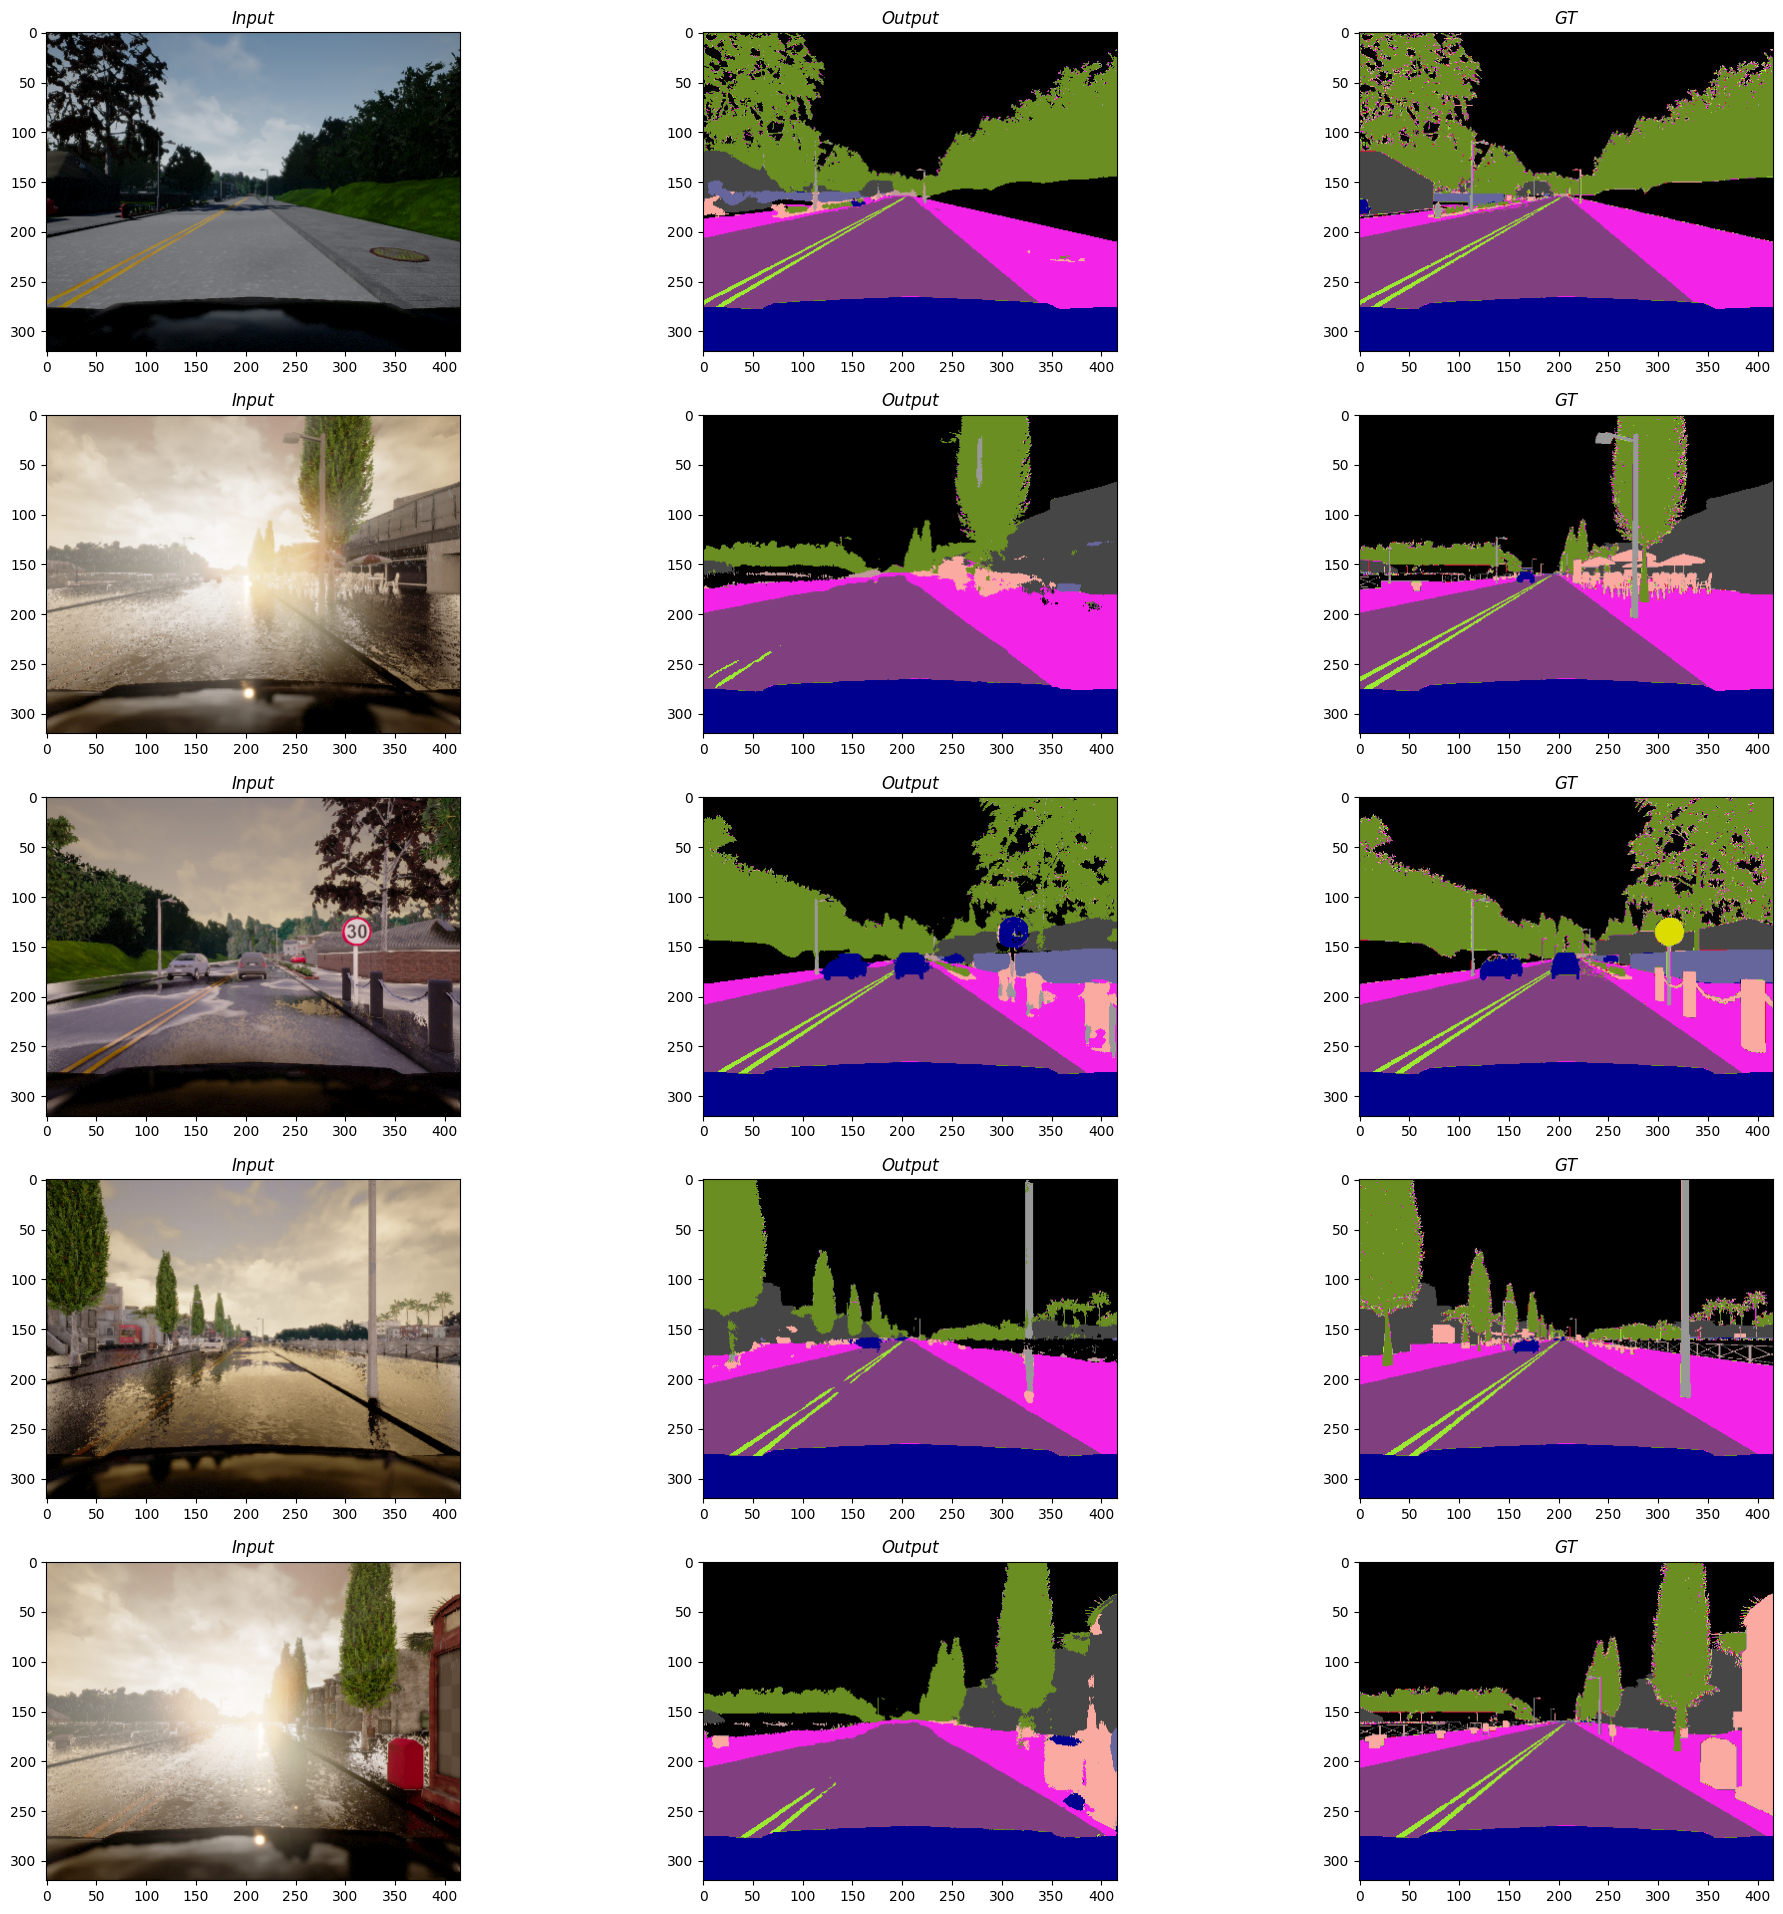

In [13]:
import matplotlib.pyplot as plt

label_colors = np.array([
[0,0,0], # unlabeled
[70,70,70], # building
[190,153,153], # fence
[250,170,160], # other
[220,20,60], # pedestrian
[153,153,153], # pole
[157,234,50], # road line
[128,64,128], # road
[244,35,232], # sidewalk
[107,142,35], # vegetation
[0,0,142], # car
[102,102,156], # wall
[220,220,0], # traffic sign
])


model.eval()


fig=plt.figure(figsize=(24, 24))
columns = 3
rows = 5
for i in range(rows):
  batch = testset[np.random.randint(len(testset))]
  img = batch['image']
  labels = batch['mask']
  img_tensor = torch.from_numpy(img).cuda()
  img_tensor = img_tensor.unsqueeze(0)
  outputs = model(img_tensor)
  out_image = outputs[0,:,:,:].detach().cpu().numpy()
  seg_mask = np.argmax(out_image,axis=0)
  seg_mask_color = label_colors[seg_mask]
  gt_mask_color = label_colors[labels[0,:,:]]

  img=img.transpose((1,2,0))
  img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
  labels = labels[0,:,:]
  ax = fig.add_subplot(rows, columns, i*columns+1)
  ax.set_title("Input", fontstyle='italic')
  plt.imshow(img)
  ax = fig.add_subplot(rows, columns, i*columns+2)
  ax.set_title("Output", fontstyle='italic')
  plt.imshow(seg_mask_color)
  ax = fig.add_subplot(rows, columns, i*columns+3)
  ax.set_title("GT", fontstyle='italic')
  plt.imshow(gt_mask_color)
  

plt.savefig(f"figure_{str(type(model))}")
plt.show()

In [17]:
import torch.optim as optim

net2 = ResNet18FCN()
net2.cuda()

# Define the loss function
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(net2.parameters(), lr=0.0002)
epochs=6
for epoch in range(epochs):  # loop over the dataset multiple times
    with tqdm(total=len(trainset), desc =str(epoch)+"/"+str(epochs), miniters=int(50),unit='img') as prog_bar:
      for i, data in enumerate(trainloader, 0):
          # get the inputs; data is a list of [inputs, labels]
          inputs = data["image"]
          labels = data["mask"]
          inputs = inputs.cuda()
          labels = labels.cuda()

          # zero the parameter gradients
          optimizer.zero_grad()

          # forward + backward + optimize
          outputs = net2(inputs)
          
          loss = criterion(outputs, labels[:,0,:,:].long())
          loss.backward()
          optimizer.step()

          prog_bar.set_postfix(**{'loss': np.round(loss.data.cpu().detach().numpy(),5)})
          prog_bar.update(4)

0/6:   0%|          | 0/4000 [00:00<?, ?img/s]

1/6:   0%|          | 0/4000 [00:00<?, ?img/s]

2/6:   0%|          | 0/4000 [00:00<?, ?img/s]

3/6:   0%|          | 0/4000 [00:00<?, ?img/s]

4/6:   0%|          | 0/4000 [00:00<?, ?img/s]

5/6:   0%|          | 0/4000 [00:00<?, ?img/s]

In [18]:
net2.eval()
ious = torch.zeros(4).cuda()
with torch.no_grad():
    with tqdm(total=len(testset), miniters=int(50),unit='img') as prog_bar:
        for data in testloader:
            # get the inputs; data is a list of [inputs, labels]
            inputs = data["image"]
            labels = data["mask"]
            inputs = inputs.cuda()
            labels = labels.cuda()
            
            outputs = net2(inputs).argmax(axis=1)

            class_iou = torch.zeros((13,))
            for class_id in range(13):
                class_labels = labels.squeeze() == class_id
                class_outputs = outputs == class_id
                #print(class_labels.shape, class_outputs.shape)
                intersection: np.ndarray = torch.logical_and(class_labels, class_outputs)
                union: np.ndarray = torch.logical_or(class_labels, class_outputs)
                #print(intersection.shape, union.shape)
                ious = torch.cat((ious, torch.nan_to_num(torch.sum(intersection, dim=(1,2)) / torch.sum(union, dim=(1,2)))), dim=0)
                # ious += (np.divide(intersection, union, out=np.zeros_like(intersection), where=(union!=0)).tolist())
                # ious += (np.where(union == 0, 0, intersection/union).tolist())

            # prog_bar.set_postfix(**{'loss': np.round(loss.data.cpu().detach().numpy(),5)})
            prog_bar.update(4)

print(f'Average IOU: {torch.mean(ious).cpu()}')

  0%|          | 0/1000 [00:00<?, ?img/s]

Average IOU: 0.46486416459083557


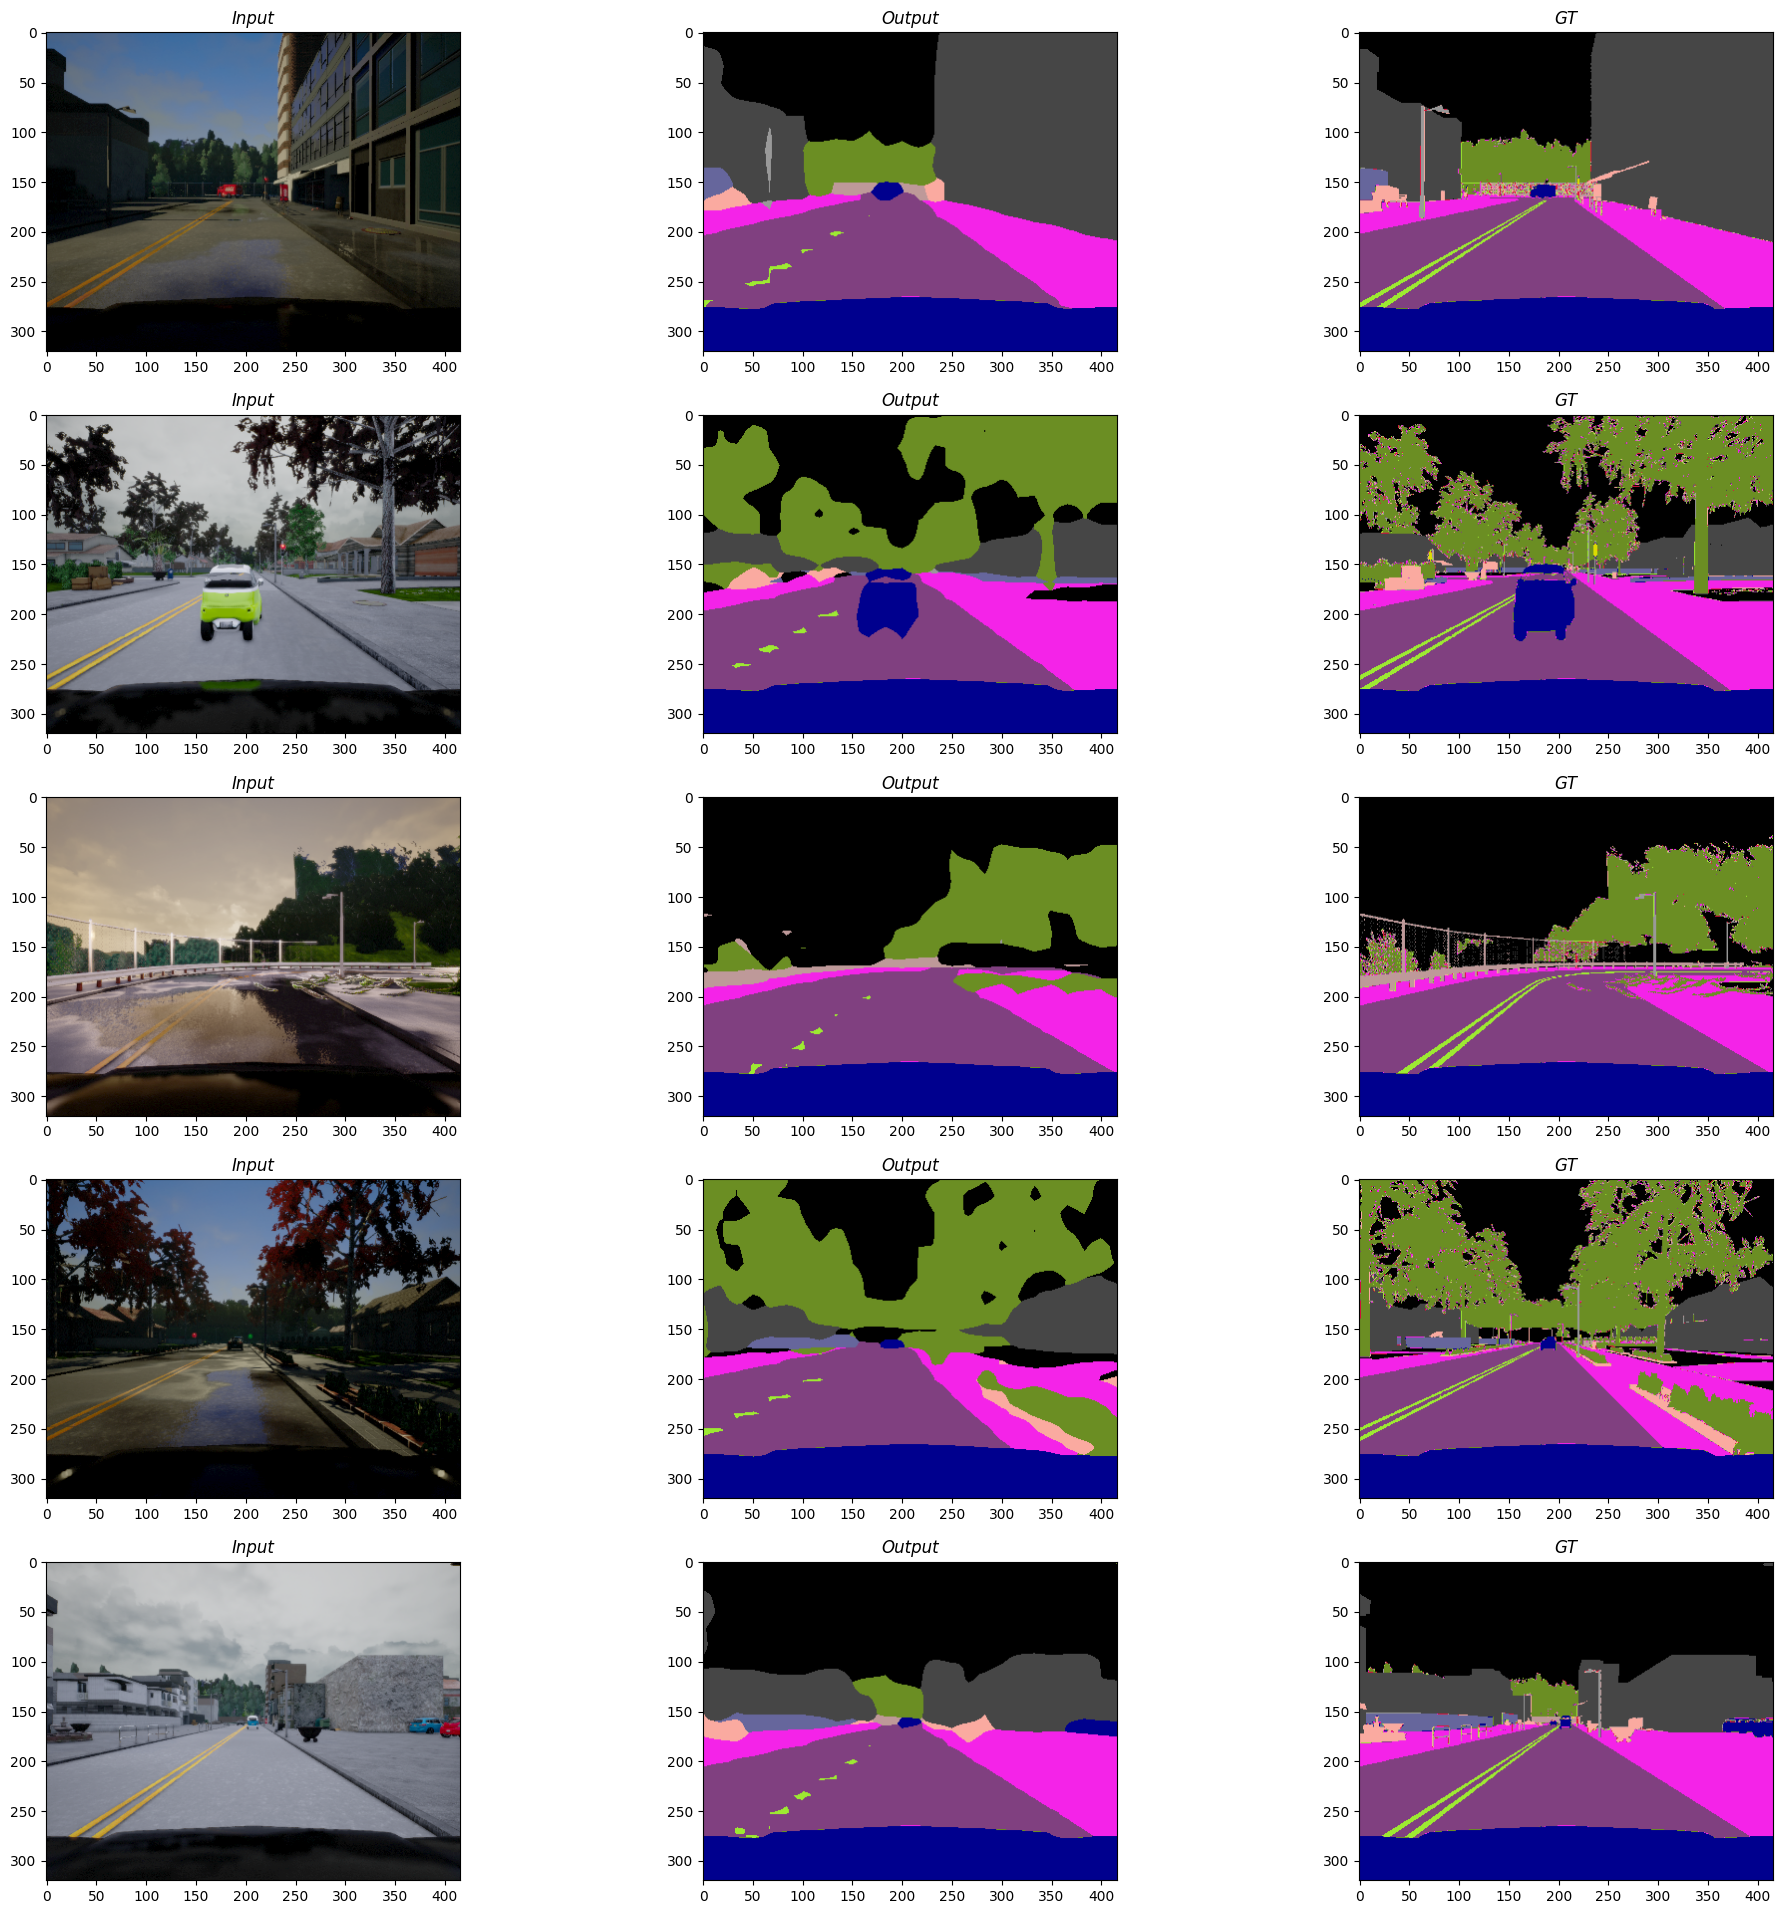

In [20]:
import matplotlib.pyplot as plt

label_colors = np.array([
[0,0,0], # unlabeled
[70,70,70], # building
[190,153,153], # fence
[250,170,160], # other
[220,20,60], # pedestrian
[153,153,153], # pole
[157,234,50], # road line
[128,64,128], # road
[244,35,232], # sidewalk
[107,142,35], # vegetation
[0,0,142], # car
[102,102,156], # wall
[220,220,0], # traffic sign
])


net2.eval()


fig=plt.figure(figsize=(24, 24))
columns = 3
rows = 5
for i in range(rows):
    batch = testset[np.random.randint(len(testset))]
    img = batch['image']
    labels = batch['mask']
    img_tensor = torch.from_numpy(img).cuda()
    img_tensor = img_tensor.unsqueeze(0)
    outputs = net2(img_tensor)
    out_image = outputs[0,:,:,:].detach().cpu().numpy()
    seg_mask = np.argmax(out_image,axis=0)
    seg_mask_color = label_colors[seg_mask]
    gt_mask_color = label_colors[labels[0,:,:]]
    
    img=img.transpose((1,2,0))
    img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
    labels = labels[0,:,:]
    ax = fig.add_subplot(rows, columns, i*columns+1)
    ax.set_title("Input", fontstyle='italic')
    plt.imshow(img)
    ax = fig.add_subplot(rows, columns, i*columns+2)
    ax.set_title("Output", fontstyle='italic')
    plt.imshow(seg_mask_color)
    ax = fig.add_subplot(rows, columns, i*columns+3)
    ax.set_title("GT", fontstyle='italic')
    plt.imshow(gt_mask_color)


plt.show()